Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import folium
from sklearn.cluster import DBSCAN

Load the Kathmandu road accidents dataset

In [ ]:

df = pd.read_csv("data/KTM_RoadAccidents_Cleaned.csv")

# Display first few rows to understand the data structure
print("Dataset Preview:")
display(df.head())

# Display basic information about the dataset
print("\nDataset Information:")
df.info()



Dataset Preview:


,Accident_ID,Year,Month,Month_Name,Accident_Date,Province,District,City / Place,Latitude,Longitude,...,Time_of_Day,Weather_Condition,Number_of_Vehicles_Involved,Injuries,Fatalities,Total_People_Killed,Emergency_Response_Time_Minutes,Victim_Gender,Victim_Age_Group,Road_User_Type
0,KV-0031,2021,1,January,2021-01-01,Bagmati,Kathmandu,Kalanki Chowk,27.702856,85.273929,...,Evening,Foggy,1,0,0,0,72,Female,Young Adult (15-24),Motorcyclist
1,KV-0051,2021,1,January,2021-01-01,Bagmati,Kathmandu,Kalanki Chowk,27.696149,85.277415,...,Morning,Rainy,2,8,0,0,35,Female,Middle Aged (45-64),Passenger
2,KV-0062,2021,1,January,2021-01-01,Bagmati,Kathmandu,Kalanki Chowk,27.698161,85.277734,...,Evening,Clear,1,7,1,1,61,Male,Middle Aged (45-64),Motorcyclist
3,KV-0209,2021,1,January,2021-01-01,Bagmati,Kathmandu,Koteshwor Chowk,27.677999,85.346622,...,Afternoon,Rainy,2,4,1,1,23,Male,Adult (25-44),Passenger
4,KV-0281,2021,1,January,2021-01-01,Bagmati,Kathmandu,Tinkune,27.686164,85.344181,...,Night,Clear,2,7,0,0,13,Female,Middle Aged (45-64),Passenger



Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1672 entries, 0 to 1671
Data columns (total 23 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Accident_ID                      1672 non-null   str    
 1   Year                             1672 non-null   int64  
 2   Month                            1672 non-null   int64  
 3   Month_Name                       1672 non-null   str    
 4   Accident_Date                    1672 non-null   str    
 5   Province                         1672 non-null   str    
 6   District                         1672 non-null   str    
 7   City / Place                     1672 non-null   str    
 8   Latitude                         1672 non-null   float64
 9   Longitude                        1672 non-null   float64
 10  Road_Type                        1672 non-null   str    
 11  Vehicle_Type                     1672 non-null   str    
 12  Accident_

Data Cleaning

In [3]:

print(f"Original dataset size: {len(df)} rows")
df = df.dropna(subset=["Latitude", "Longitude"])
print(f"After removing missing coordinates: {len(df)} rows")

# Remove duplicate records to avoid biased clustering
df = df.drop_duplicates()
print(f"After removing duplicates: {len(df)} rows")

Original dataset size: 1672 rows
After removing missing coordinates: 1672 rows
After removing duplicates: 1672 rows


Simple scatter plot to see the distribution of accidents

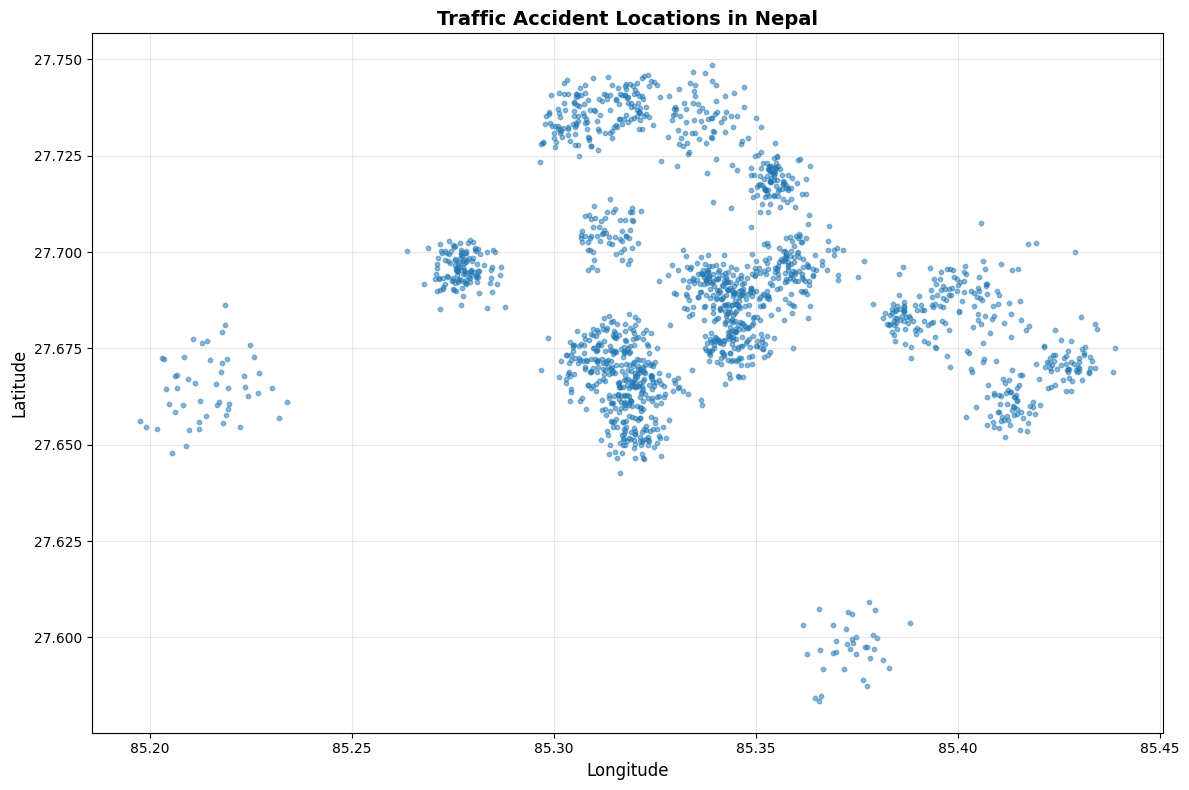

In [4]:

plt.figure(figsize=(12, 8))
plt.scatter(df["Longitude"], df["Latitude"], alpha=0.5, s=10)
plt.xlabel("Longitude", fontsize=12)
plt.ylabel("Latitude", fontsize=12)
plt.title("Traffic Accident Locations in Nepal", fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Prepare Data for DBSCAN Clustering


In [5]:
# Convert latitude and longitude to radians for haversine distance calculation
# Haversine formula calculates distances on a sphere (Earth)
coords_radians = np.radians(df[["Latitude", "Longitude"]].values)

# Define clustering parameters
eps_km = 0.4  # Maximum distance between two points to be considered neighbors (in km) for ktm(0.5),nepal(0.005)
eps_radians = eps_km / 6371.0  # Convert km to radians (Earth's radius = 6371 km)
min_samples = 3  # Minimum number of points to form a dense region (cluster)

print(f"DBSCAN Parameters:")
print(f"  - eps (radius): {eps_km} km")
print(f"  - min_samples: {min_samples} points")
print(f"  - metric: haversine (accounts for Earth's curvature)")


DBSCAN Parameters:
  - eps (radius): 0.4 km
  - min_samples: 3 points
  - metric: haversine (accounts for Earth's curvature)


Apply DBSCAN Clustering Algorithm

In [6]:
# Initialize DBSCAN model with specified parameters
# - ball_tree algorithm is efficient for haversine metric
# - haversine metric calculates great-circle distances
dbscan_model = DBSCAN(
    eps=eps_radians,
    min_samples=min_samples,
    algorithm='ball_tree',
    metric='haversine'
)

# Fit the model and predict cluster labels
# Cluster -1 represents noise (outlier points that don't belong to any cluster)
df["cluster"] = dbscan_model.fit_predict(coords_radians)


Analyze Clustering Results

In [7]:
# Display clustering statistics
num_clusters = df["cluster"].nunique() - 1  # Exclude -1 (noise)
num_noise = (df["cluster"] == -1).sum()
num_clustered = (df["cluster"] != -1).sum()

print("\n" + "="*60)
print("DBSCAN CLUSTERING RESULTS")
print("="*60)
print(f"Total accidents analyzed: {len(df)}")
print(f"Number of clusters identified: {num_clusters}")
print(f"Clustered points (hotspots): {num_clustered} ({num_clustered/len(df)*100:.1f}%)")
print(f"Noise points (isolated accidents): {num_noise} ({num_noise/len(df)*100:.1f}%)")
print("\nTop 10 Largest Clusters:")
print(df[df["cluster"] != -1]["cluster"].value_counts().head(10))



DBSCAN CLUSTERING RESULTS
Total accidents analyzed: 1672
Number of clusters identified: 22
Clustered points (hotspots): 1611 (96.4%)
Noise points (isolated accidents): 61 (3.6%)

Top 10 Largest Clusters:
cluster
1     423
3     366
4     218
9     139
0     124
2      94
7      61
5      56
6      55
11     21
Name: count, dtype: int64


Visualize Accident Hotspot Clusters

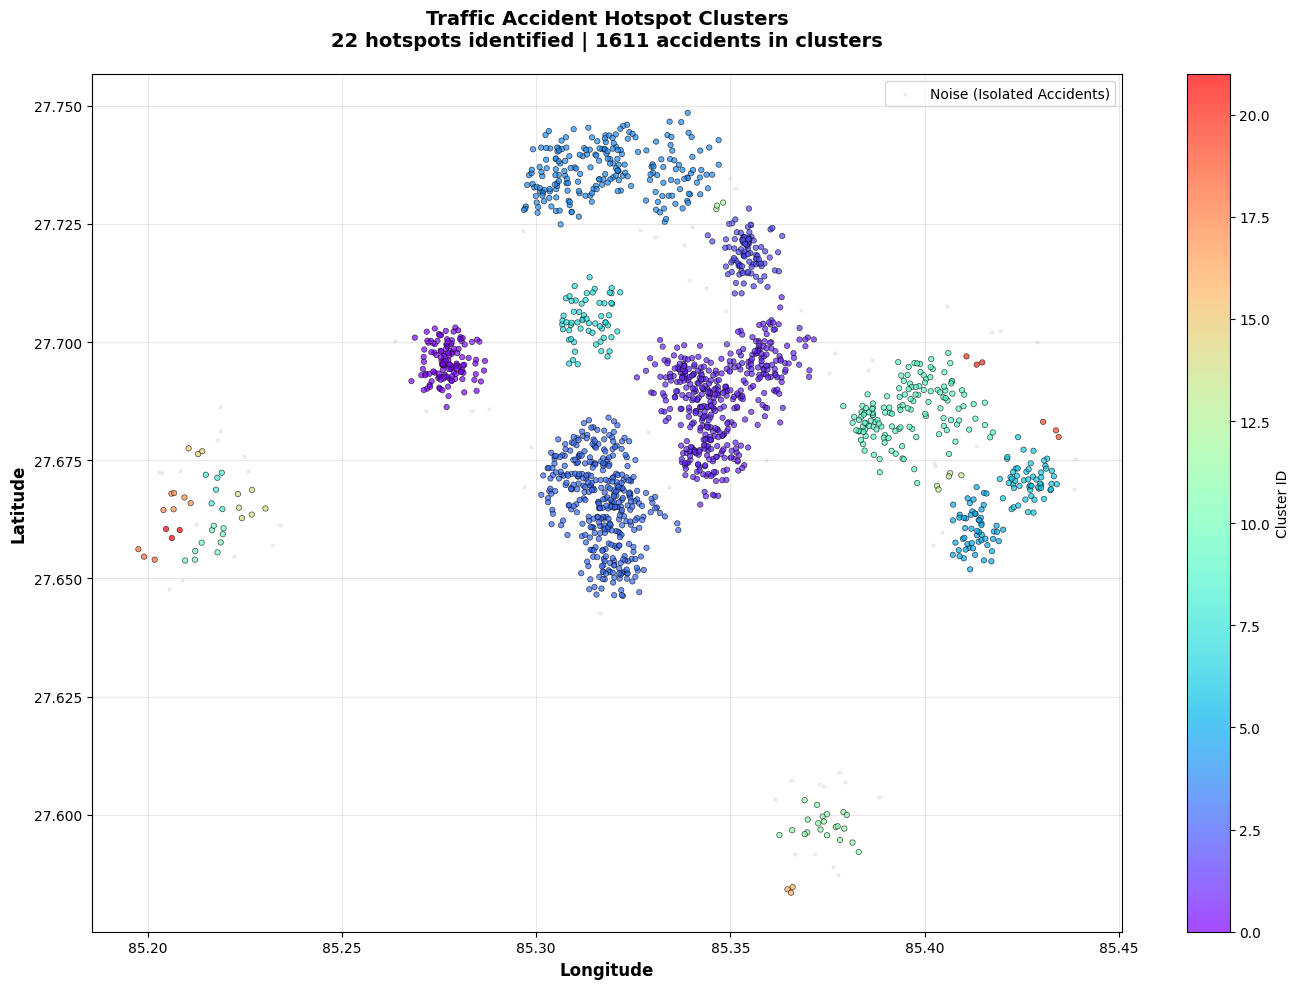

In [8]:
# Create a detailed visualization separating noise from clusters
noise_points = df[df["cluster"] == -1]
clustered_points = df[df["cluster"] != -1]

fig, ax = plt.subplots(figsize=(14, 10))

# Plot noise points in light grey
ax.scatter(
    noise_points["Longitude"],
    noise_points["Latitude"],
    c="lightgrey",
    s=5,
    alpha=0.3,
    label="Noise (Isolated Accidents)"
)

# Plot clustered points with rainbow colors
scatter = ax.scatter(
    clustered_points["Longitude"],
    clustered_points["Latitude"],
    c=clustered_points["cluster"],
    cmap="rainbow",
    s=15,
    alpha=0.7,
    edgecolors='black',
    linewidth=0.5
)

# Add colorbar to show cluster IDs
cbar = plt.colorbar(scatter, ax=ax, label="Cluster ID")
cbar.ax.tick_params(labelsize=10)

# Customize plot
ax.set_xlabel("Longitude", fontsize=12, fontweight='bold')
ax.set_ylabel("Latitude", fontsize=12, fontweight='bold')
ax.set_title(
    f"Traffic Accident Hotspot Clusters\n"
    f"{num_clusters} hotspots identified | {num_clustered} accidents in clusters",
    fontsize=14,
    fontweight='bold',
    pad=20
)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Analyze Cluster Locations

In [9]:
# Group accidents by cluster and identify top locations
if "City / Place" in df.columns:
    cluster_summary = df[df["cluster"] != -1].groupby("cluster").agg(
        accident_count=("City / Place", "count"),
        top_location=("City / Place", lambda x: x.value_counts().index[0] if len(x) > 0 else "Unknown"),
        avg_latitude=("Latitude", "mean"),
        avg_longitude=("Longitude", "mean")
    ).sort_values("accident_count", ascending=False)
    
    print("\n" + "="*60)
    print("TOP 15 ACCIDENT HOTSPOT CLUSTERS")
    print("="*60)
    display(cluster_summary.head(15))



TOP 15 ACCIDENT HOTSPOT CLUSTERS


,accident_count,top_location,avg_latitude,avg_longitude
cluster,,,,
1,423,Koteshwor Chowk,27.688025,85.347459
3,366,Lagankhel,27.666064,85.317086
4,218,Balaju Bypass,27.736159,85.318452
9,139,Thimi Chowk,27.685385,85.395685
0,124,Kalanki Chowk,27.695881,85.277290
2,94,Chabahil,27.718702,85.354322
7,61,Ratnapark,27.704612,85.313494
5,56,Suryabinayak,27.660303,85.413083
6,55,Bhaktapur Durbar,27.670700,85.426917


Map

In [ ]:
#Calculate center of the map (mean of all coordinates)
center_lat = df["Latitude"].mean()
center_lon = df["Longitude"].mean()

# Create base map centered on the accident locations
accident_map = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=12,
    tiles='OpenStreetMap'
)

# Add cluster markers with different colors
# Define color palette for clusters
colors = ['red', 'blue', 'green', 'purple', 'orange', 'darkred',
          'lightred', 'black', 'darkblue', 'darkgreen', 'cadetblue',
          'darkpurple', 'pink', 'lightblue', 'lightgreen', 'gray','gold','lightgray','black','cyan','magenta']

# Add clustered points
for cluster_id in sorted(df[df["cluster"] != -1]["cluster"].unique()):
    cluster_data = df[df["cluster"] == cluster_id]
    color = colors[cluster_id % len(colors)]
    
    for _, row in cluster_data.iterrows():
        folium.CircleMarker(
            location=[row["Latitude"], row["Longitude"]],
            radius=4,
            color=color,
            fill=True,
            fillColor=color,
            fillOpacity=0.6,
            popup=f"Cluster {cluster_id}"
        ).add_to(accident_map)

# Add noise points in grey
for _, row in noise_points.iterrows():
    folium.CircleMarker(
        location=[row["Latitude"], row["Longitude"]],
        radius=2,
        color='gray',
        fill=True,
        fillColor='gray',
        fillOpacity=0.3,
        popup="Isolated Accident"
    ).add_to(accident_map)

# Save the map
accident_map.save("fig/accident_hotspots.html")
print("\nInteractive map saved as 'fig/accident_hotspots.html'")

# Display map in notebook
accident_map



Interactive map saved as 'accident_hotspots.html'
